# Fetch landuse segmentation dataset (Sentinel-2 + OSM + Cartofriches)

Builds the training data for `train_unet_landuse.ipynb`: RGB Sentinel-2 tiles paired with
5-class masks (fond / parking / industriel-commercial / friche / residentiel).

Resumes the segmentation attempt documented (and deliberately halted) in
`docs/roadmap_segmentation.md` — read it first. The first attempt failed because of extreme
class imbalance and too little data (66 tiles, one AOI). This notebook applies the two
priority fixes from that doc's §6:
- multiple distinct AOIs (bassin minier + Calais/Boulogne, see `helpers/landuse_aois.py`)
  instead of a single enlarged one — more tiles, more visual diversity per rare class
- (the second fix, class-weighted loss, lives in `train_unet_landuse.ipynb`)

It also adds a **residentiel** class (OSM `landuse=residential`), absent from the original
roadmap: without it, residential areas had no correct class to fall into and the model was
routing them into parking/friche instead (visually ambiguous at 10m/pixel).

**OSM multipolygon relations are now included** (`helpers/geo_fetch.fetch_osm_polygons`),
not just plain ways -- large parking lots (the >1500m^2 loi APER threshold this project
targets) are often mapped as a relation (outer ring + inner-ring holes for
landscaping/lighting islands) rather than a simple way, so way-only fetching was silently
under-counting exactly the biggest, most relevant parkings. Relation holes are rasterized
back to background, not left as the outer class.

**This is long-running and network-heavy**: for each AOI it fetches a Sentinel-2 scene
(Planetary Computer STAC), OSM ways+relations (Overpass API) and Cartofriches (Cerema WFS).
Expect several minutes total. Extend `LANDUSE_AOIS` in `helpers/landuse_aois.py` for more tiles.

**Re-running this notebook regenerates `data/landuse/masks` and `masks_preview`** (and
re-fetches images) — needed since previously generated masks don't have the residential
class or the relation-derived polygons burned in. `train_unet_landuse.ipynb` must be
re-run afterwards too.

In [1]:
import sys
import time
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import numpy as np
import planetary_computer
import pystac_client
import rasterio
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds, transform as window_transform
from PIL import Image

from helpers.geo_fetch import fetch_cartofriches_polygons, fetch_osm_polygons
from helpers.image_utils import crop_to_multiple
from helpers.landuse_aois import LANDUSE_AOIS
from helpers.mask_rasterize import CLASS_NAMES, colorize_mask, rasterize_landuse_mask

print(f"{len(LANDUSE_AOIS)} AOIs configured: {[aoi.name for aoi in LANDUSE_AOIS]}")

13 AOIs configured: ['dunkerque', 'lens', 'douai', 'valenciennes', 'bethune', 'calais', 'boulogne_sur_mer', 'rouen', 'istres', 'maubeuge', 'saint_omer', 'arras', 'annemasse']


### 1/ Configuration

In [2]:
from datetime import date, timedelta

TILE_SIZE = 256  # matches docs/roadmap_segmentation.md's validated tile size
DATE_END = date.today()
DATE_START = DATE_END - timedelta(days=180)
MAX_CLOUD_COVER = 20

DATA_DIR = Path.cwd().parent / "data" / "landuse"
IMAGES_DIR = DATA_DIR / "images"
MASKS_DIR = DATA_DIR / "masks"
MASKS_PREVIEW_DIR = DATA_DIR / "masks_preview"
for d in (IMAGES_DIR, MASKS_DIR, MASKS_PREVIEW_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Tiles -> {IMAGES_DIR} / {MASKS_DIR} (preview: {MASKS_PREVIEW_DIR})")

Tiles -> /Users/erizzolio/Work/Alyra/SOLSCAN/data/landuse/images / /Users/erizzolio/Work/Alyra/SOLSCAN/data/landuse/masks (preview: /Users/erizzolio/Work/Alyra/SOLSCAN/data/landuse/masks_preview)


### 2/ Sentinel-2 fetch helper

Same STAC search as `api/inference.fetch_sentinel2_rgb`, but this one also returns the
window's CRS/transform/shape — needed to rasterize the mask pixel-aligned with the image,
which the API version doesn't need (it's display-only).

In [3]:
def fetch_sentinel2_scene(bbox, date_start: str, date_end: str, max_cloud_cover: float):
    """@return dict with image/crs/transform/shape/cloud_cover/datetime, or None if no scene found."""
    catalog = pystac_client.Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
        modifier=planetary_computer.sign_inplace,
    )
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=f"{date_start}/{date_end}",
        query={"eo:cloud_cover": {"lt": max_cloud_cover}},
    )
    items = sorted(search.item_collection(), key=lambda it: it.properties["eo:cloud_cover"])
    if not items:
        return None
    item = items[0]

    with rasterio.open(item.assets["B04"].href) as src:
        scene_crs = src.crs
        bounds = transform_bounds("EPSG:4326", scene_crs, *bbox)
        window = from_bounds(*bounds, transform=src.transform)
        win_transform = window_transform(window, src.transform)

    arrays = []
    for band in ("B04", "B03", "B02"):
        with rasterio.open(item.assets[band].href) as src:
            arrays.append(src.read(1, window=window))

    rgb_raw = np.stack(arrays, axis=-1)
    rgb_uint8 = np.clip(rgb_raw / 3000 * 255, 0, 255).astype(np.uint8)
    image = Image.fromarray(rgb_uint8, mode="RGB")

    return {
        "image": image,
        "crs": scene_crs,
        "transform": win_transform,
        "shape": (arrays[0].shape[0], arrays[0].shape[1]),  # (height, width)
        "cloud_cover": item.properties.get("eo:cloud_cover"),
        "datetime": item.properties.get("datetime"),
    }

### 3/ Main loop: fetch + rasterize + tile, per AOI

Each AOI is wrapped in a `try/except` so one failure (no scene, network hiccup) doesn't
abort the whole run. A short sleep between AOIs keeps Overpass's public instance happy.

In [ ]:
tile_stats = []  # one dict per AOI, for the summary below

for aoi in LANDUSE_AOIS:
    print(f"\n=== {aoi.name} (bbox={aoi.bbox}) ===")
    try:
        scene = fetch_sentinel2_scene(aoi.bbox, str(DATE_START), str(DATE_END), MAX_CLOUD_COVER)
        if scene is None:
            print(f"[{aoi.name}] no Sentinel-2 scene found, skipping")
            continue
        print(f"[{aoi.name}] scene {scene['datetime']}, cloud cover {scene['cloud_cover']:.1f}%")

        osm = fetch_osm_polygons(aoi.bbox)
        print(
            f"[{aoi.name}] OSM: {len(osm['parking'])} parking, {len(osm['industrial'])} industrial/commercial, "
            f"{len(osm['residential'])} residential polygon(s) (ways + multipolygon relations), "
            f"{len(osm['holes'])} relation hole(s)"
        )
        time.sleep(2)  # be nice to the public Overpass instance

        friches = fetch_cartofriches_polygons(aoi.dept_insee_prefix, aoi.bbox)
        print(f"[{aoi.name}] Cartofriches: {len(friches)} friche(s) in AOI")

        mask = rasterize_landuse_mask(
            scene["crs"], scene["transform"], scene["shape"],
            osm_parking=osm["parking"], osm_industrial=osm["industrial"], cartofriches_friches=friches,
            osm_residential=osm["residential"], osm_holes=osm["holes"],
        )
        class_ids, class_counts = np.unique(mask, return_counts=True)
        pixel_counts = {CLASS_NAMES[c]: int(n) for c, n in zip(class_ids, class_counts)}
        print(f"[{aoi.name}] mask pixel counts: {pixel_counts}")

        image = crop_to_multiple(scene["image"], TILE_SIZE)
        mask_image = crop_to_multiple(Image.fromarray(mask), TILE_SIZE)
        n_cols = image.width // TILE_SIZE
        n_rows = image.height // TILE_SIZE
        if n_rows == 0 or n_cols == 0:
            print(f"[{aoi.name}] AOI too small for a {TILE_SIZE}px tile, skipping")
            continue

        n_tiles = 0
        for row in range(n_rows):
            for col in range(n_cols):
                box = (col * TILE_SIZE, row * TILE_SIZE, (col + 1) * TILE_SIZE, (row + 1) * TILE_SIZE)
                name = f"{aoi.name}_tile_{row}_{col}.png"
                image.crop(box).save(IMAGES_DIR / name)
                tile_mask = mask_image.crop(box)
                tile_mask.save(MASKS_DIR / name)
                colorize_mask(np.array(tile_mask)).save(MASKS_PREVIEW_DIR / name)
                n_tiles += 1

        print(f"[{aoi.name}] saved {n_tiles} tiles ({n_cols}x{n_rows})")
        tile_stats.append({"aoi": aoi.name, "n_tiles": n_tiles, "pixel_counts": pixel_counts})

    except Exception as exc:
        print(f"[{aoi.name}] FAILED: {exc}")

    time.sleep(2)

### 4/ Summary

In [5]:
total_tiles = sum(s["n_tiles"] for s in tile_stats)
print(f"Total: {total_tiles} tiles across {len(tile_stats)}/{len(LANDUSE_AOIS)} AOIs")
for s in tile_stats:
    print(f"  {s['aoi']}: {s['n_tiles']} tiles")

# Aggregate class pixel counts across all successfully processed AOIs -- same imbalance
# check as docs/roadmap_segmentation.md §5, to see if the multi-AOI fix actually helped.
total_pixel_counts = {name: 0 for name in CLASS_NAMES}
for s in tile_stats:
    for name, count in s["pixel_counts"].items():
        total_pixel_counts[name] += count
total_pixels = sum(total_pixel_counts.values())
print("\nClass balance across the whole dataset:")
for name, count in total_pixel_counts.items():
    pct = 100 * count / total_pixels if total_pixels else 0
    print(f"  {name}: {count} px ({pct:.3f}%)")

Total: 665 tiles across 11/13 AOIs
  dunkerque: 64 tiles
  lens: 64 tiles
  douai: 48 tiles
  valenciennes: 64 tiles
  bethune: 40 tiles
  boulogne_sur_mer: 40 tiles
  rouen: 64 tiles
  istres: 72 tiles
  maubeuge: 64 tiles
  arras: 64 tiles
  annemasse: 81 tiles

Class balance across the whole dataset:
  Fond: 43121337 px (86.587%)
  Parking: 109980 px (0.221%)
  Industriel/commercial: 1495303 px (3.003%)
  Friche: 464020 px (0.932%)
  Residentiel: 4610465 px (9.258%)


### 5/ Visual sanity check

A few random tiles with their raw mask and colorized mask, to catch alignment/rasterization bugs before training.

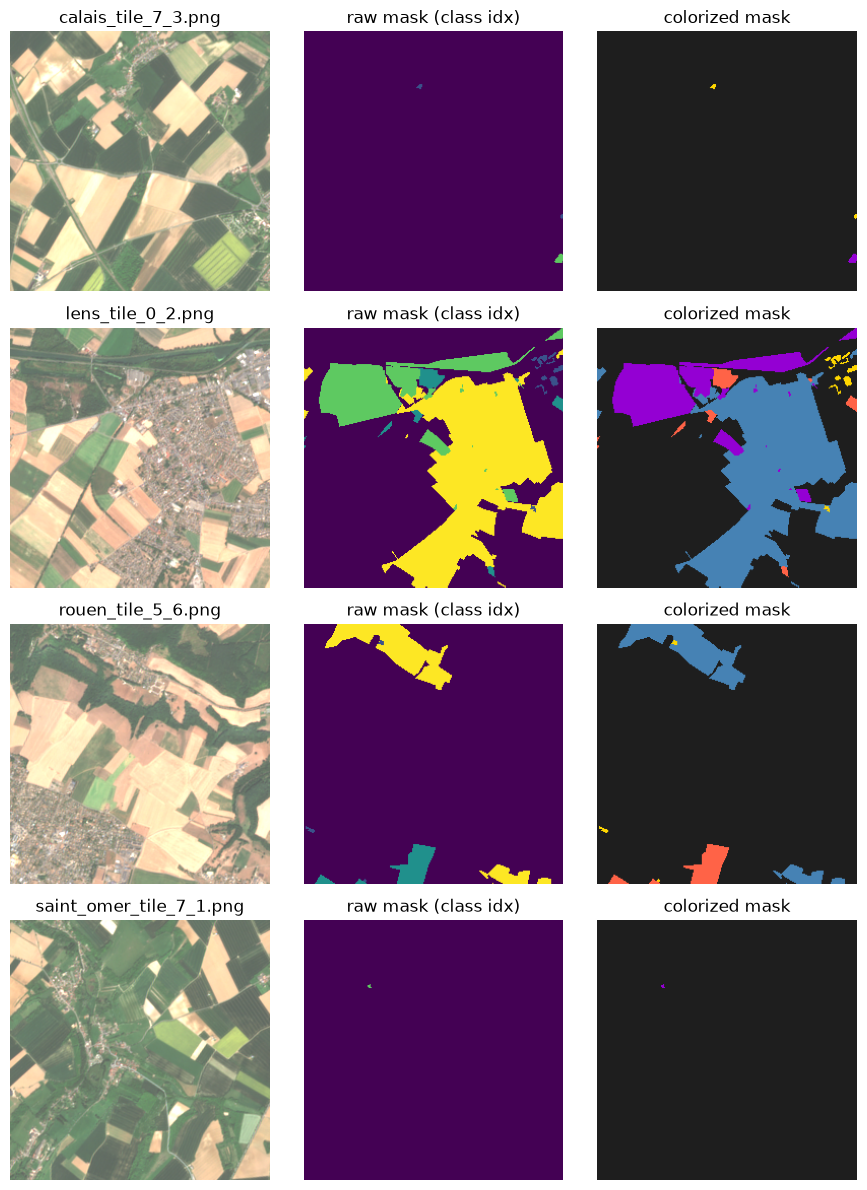

In [6]:
import random

import matplotlib.pyplot as plt

sample_names = random.sample(sorted(p.name for p in IMAGES_DIR.glob("*.png")), k=min(4, total_tiles))

fig, axes = plt.subplots(len(sample_names), 3, figsize=(9, 3 * len(sample_names)))
for i, name in enumerate(sample_names):
    img = Image.open(IMAGES_DIR / name)
    mask_preview = Image.open(MASKS_PREVIEW_DIR / name)
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(name)
    axes[i, 1].imshow(np.array(Image.open(MASKS_DIR / name)), vmin=0, vmax=len(CLASS_NAMES) - 1)
    axes[i, 1].set_title("raw mask (class idx)")
    axes[i, 2].imshow(mask_preview)
    axes[i, 2].set_title("colorized mask")
    for ax in axes[i]:
        ax.axis("off")
plt.tight_layout()
plt.show()